# Word2Vec training

This notebook is based on the [word2vec-pytorch](https://github.com/OlgaChernytska/word2vec-pytorch/tree/18d4f24c4d82dde76de9f6e4d88bbcbcf68befc2) repo.

In [1]:
!wget https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.train.tokens
!wget https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.valid.tokens

--2025-11-23 18:39:10--  https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.train.tokens
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8003::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10797148 (10M) [text/plain]
Saving to: ‘wiki.train.tokens’

wiki.train.tokens   100%[===================>]  10.30M  26.5MB/s    in 0.4s    

2025-11-23 18:39:11 (26.5 MB/s) - ‘wiki.train.tokens’ saved [10797148/10797148]

--2025-11-23 18:39:11--  https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.valid.tokens
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8001::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubuserc

In [2]:
!pip install nltk seaborn matplotlib gensim

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (

У торча есть библиотека torchtext для работе с текстами, но она deprecated (и на багованно ставится), поэтому возьмем `nltk`

In [2]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import WordPunctTokenizer


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

In [3]:
TRAIN_TOKENS = './wiki.train.tokens'
VALID_TOKENS = './wiki.valid.tokens'

SKIPGRAM_N_WORDS = 4
MIN_WORD_FREQUENCY = 20
MAX_SEQUENCE_LENGTH = 256

EMBED_DIM = 256
EMBED_MAX_NORM = 1
BATCH_SIZE = 16
NUM_EPOCHS = 20

In [4]:
import torch

In [5]:
tokens = torch.tensor([1, 2, 2, 3, 2, 4, 0, 0])
tokens

tensor([1, 2, 2, 3, 2, 4, 0, 0])

In [6]:
import torch.nn as nn


emb = nn.Embedding(6, 16, padding_idx=0)

emb.weight

Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0189, -1.5162, -1.4633, -0.7723, -0.9154,  0.3945,  1.8879,  1.3893,
         -1.9424, -0.6620, -0.5994, -0.9160, -0.0884, -0.2371,  1.1531, -0.8713],
        [-0.2180,  0.1346,  0.3166, -0.3863, -0.6169, -0.8293, -1.1669,  0.0078,
          0.3797, -1.1118, -0.2536, -0.2297,  0.9033, -0.7911, -1.0219,  0.8218],
        [-0.3948, -1.6118, -0.1769,  0.8638, -0.2446,  0.8165, -1.2619,  0.9054,
          0.7022,  0.6853, -0.4102, -3.1178, -1.1268, -2.4780, -0.3896,  0.7296],
        [-1.5397,  1.3030, -1.0064, -1.5316, -0.1761, -2.2637,  0.8478, -1.4324,
         -1.0091, -0.2912,  0.6697, -0.9197, -0.4197,  0.3803,  1.1361, -0.1582],
        [ 0.5876,  1.3824,  1.3035,  0.6878, -0.4428, -0.5192,  1.6576,  1.5022,
         -1.0585,  1.4265, -1.7322, -0.4831,  0.9786, -1.4229, -1.2801,  0.0993]],

In [7]:
embeds = emb(tokens)

In [8]:
embeds

tensor([[ 0.0189, -1.5162, -1.4633, -0.7723, -0.9154,  0.3945,  1.8879,  1.3893,
         -1.9424, -0.6620, -0.5994, -0.9160, -0.0884, -0.2371,  1.1531, -0.8713],
        [-0.2180,  0.1346,  0.3166, -0.3863, -0.6169, -0.8293, -1.1669,  0.0078,
          0.3797, -1.1118, -0.2536, -0.2297,  0.9033, -0.7911, -1.0219,  0.8218],
        [-0.2180,  0.1346,  0.3166, -0.3863, -0.6169, -0.8293, -1.1669,  0.0078,
          0.3797, -1.1118, -0.2536, -0.2297,  0.9033, -0.7911, -1.0219,  0.8218],
        [-0.3948, -1.6118, -0.1769,  0.8638, -0.2446,  0.8165, -1.2619,  0.9054,
          0.7022,  0.6853, -0.4102, -3.1178, -1.1268, -2.4780, -0.3896,  0.7296],
        [-0.2180,  0.1346,  0.3166, -0.3863, -0.6169, -0.8293, -1.1669,  0.0078,
          0.3797, -1.1118, -0.2536, -0.2297,  0.9033, -0.7911, -1.0219,  0.8218],
        [-1.5397,  1.3030, -1.0064, -1.5316, -0.1761, -2.2637,  0.8478, -1.4324,
         -1.0091, -0.2912,  0.6697, -0.9197, -0.4197,  0.3803,  1.1361, -0.1582],
        [ 0.0000,  0.0

In [9]:
tokenizer = WordPunctTokenizer()

In [10]:
with open(TRAIN_TOKENS, 'r') as file:
    lines = file.readlines()

lines

[' \n',
 ' = Valkyria Chronicles III = \n',
 ' \n',
 ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . <unk> the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more <unk> f

In [11]:
def load_and_preprocess_dataset(path):
    with open(path, 'r') as file:
        lines = file.readlines()

    data = list(filter(
        lambda sent: len(sent) > SKIPGRAM_N_WORDS * 2,
        map(tokenizer.tokenize, lines)
    ))
    return data

In [12]:
train_data = load_and_preprocess_dataset(TRAIN_TOKENS)
valid_data = load_and_preprocess_dataset(VALID_TOKENS)

total_train_tokens = sum(len(sent) for sent in train_data)
total_valid_tokens = sum(len(sent) for sent in valid_data)

print(f'Num sentences: train - {len(train_data)}, valid - {len(valid_data)}')
print(f'Total tokens: train - {total_train_tokens}, valid - {total_valid_tokens}')
print(f'Average tokens in sentence: {total_train_tokens / len(train_data):.2f}')

Num sentences: train - 18251, valid - 1969
Total tokens: train - 2149387, valid - 236601
Average tokens in sentence: 117.77


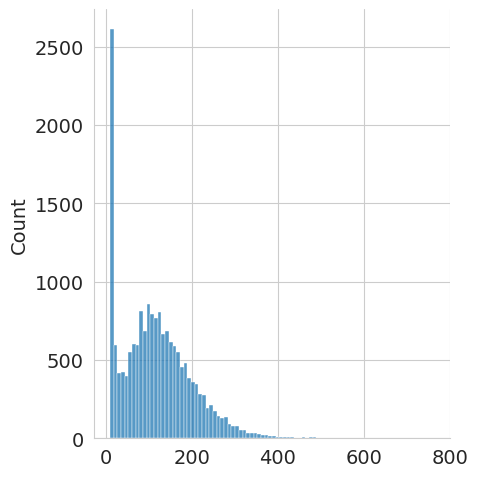

In [13]:
_ = sns.displot([len(sent) for sent in train_data])

In [14]:
train_data[0]

['Senjō',
 'no',
 'Valkyria',
 '3',
 ':',
 '<',
 'unk',
 '>',
 'Chronicles',
 '(',
 'Japanese',
 ':',
 '戦場のヴァルキュリア3',
 ',',
 'lit',
 '.',
 'Valkyria',
 'of',
 'the',
 'Battlefield',
 '3',
 ')',
 ',',
 'commonly',
 'referred',
 'to',
 'as',
 'Valkyria',
 'Chronicles',
 'III',
 'outside',
 'Japan',
 ',',
 'is',
 'a',
 'tactical',
 'role',
 '@-@',
 'playing',
 'video',
 'game',
 'developed',
 'by',
 'Sega',
 'and',
 'Media',
 '.',
 'Vision',
 'for',
 'the',
 'PlayStation',
 'Portable',
 '.',
 'Released',
 'in',
 'January',
 '2011',
 'in',
 'Japan',
 ',',
 'it',
 'is',
 'the',
 'third',
 'game',
 'in',
 'the',
 'Valkyria',
 'series',
 '.',
 '<',
 'unk',
 '>',
 'the',
 'same',
 'fusion',
 'of',
 'tactical',
 'and',
 'real',
 '@-@',
 'time',
 'gameplay',
 'as',
 'its',
 'predecessors',
 ',',
 'the',
 'story',
 'runs',
 'parallel',
 'to',
 'the',
 'first',
 'game',
 'and',
 'follows',
 'the',
 '"',
 'Nameless',
 '"',
 ',',
 'a',
 'penal',
 'military',
 'unit',
 'serving',
 'the',
 'nation',
 

In [15]:
from itertools import chain
from typing import Iterable, Union

In [16]:
from collections import Counter
from operator import itemgetter

In [17]:
class VocabPseudoVectorized:
    def __init__(self, train_data: Iterable[str],
                 unk_label: str = "<UNK>",
                 unk_cutoff: int = MIN_WORD_FREQUENCY):
        raw_counts = Counter(train_data)
        for token, frequency in tuple(raw_counts.items()):
            if frequency >= unk_cutoff:
                continue
            raw_counts.pop(token)
        remaining_tokens = list(raw_counts.keys())
        # add UNK token:
        remaining_tokens[0:0] = [unk_label]

        self._token2idx = {
            token: id_ for id_, token in enumerate(remaining_tokens)
        }
        self._idx2token = {
            id_: token for id_, token in enumerate(remaining_tokens)
        }

    def _fetch_index(self, item: str):
        return self._token2idx.get(item, 0)  # <--- UNK token

    def __getitem__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        if isinstance(item, Iterable) and not isinstance(item, str):
            return list(map(self.__getitem__, item))
    
        return self._fetch_index(item)

    def __call__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        return self[item]

    def __len__(self, ):
        return len(self._token2idx)

    def __contains__(self, item):
        return item in self._token2idx

    def lookup(self, item: Union[str, Iterable[str]]):
        result = []
        if isinstance(item, str):
            return self[item]
        for x in item:
            result.append(self.lookup(x))
        return result

    def get_itos(self, items: Iterable[str]):
        if isinstance(items, torch.Tensor):
            items = items.detach().cpu().tolist()
        return [self._idx2token[i] for i in items]

In [18]:
vocab = VocabPseudoVectorized(chain(*train_data))

VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

Vocab size: 8716


In [19]:
train_data[102]

['National',
 'Mission',
 ';',
 'Society',
 'for',
 'the',
 'Preservation',
 'of',
 'Christian',
 'Knowledge',
 ',',
 '1916']

In [20]:
train_data[123]

['Flower', 'Fairies', 'of', 'the', 'Trees', ';', 'Blackie', ',', '1940']

In [21]:
vocab[train_data[123]]

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [22]:
vocab.get_itos(vocab[train_data[123]]) == train_data[123]  # Правдиво только если не встретится неизвестный токен

True

In [23]:
vocab[train_data[123]]

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [24]:
vocab.get_itos(vocab[train_data[123]])

['Flower', 'Fairies', 'of', 'the', 'Trees', ';', 'Blackie', ',', '1940']

In [25]:
vocab.lookup(train_data[123])

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [26]:
vocab(['skibididopdopdopyesyesyes'])

[0]

In [27]:
vocab.lookup(["ASDASD", "asdaa", ["cat", "dog"]])

[0, 0, [4016, 3902]]

In [28]:
vocab["Mission"]

1867

In [29]:
vocab["<UNK>"]

0

In [30]:
vocab("cat")

4016

In [31]:
vocab("13123123123")

0

In [32]:
def collate_fn(batch):
    """
    # T_1, T_2, T_3, T_4
    Collate_fn for Skip-Gram model to be used with Dataloader.
    `batch` is expected to be list of text paragrahs.

    Context is represented as N=SKIPGRAM_N_WORDS past words 
    and N=SKIPGRAM_N_WORDS future words.

    Long paragraphs will be truncated to contain
    no more that MAX_SEQUENCE_LENGTH tokens.

    Each element in `batch_input` is a middle word.
    Each element in `batch_output` is a context word.
    """
    batch_input, batch_output = [], []
    for text in batch:
        text_tokens_ids = vocab(text)

        if MAX_SEQUENCE_LENGTH:
            text_tokens_ids = text_tokens_ids[:MAX_SEQUENCE_LENGTH]

        for idx in range(len(text_tokens_ids) - SKIPGRAM_N_WORDS * 2):
            token_id_sequence = text_tokens_ids[idx : (idx + SKIPGRAM_N_WORDS * 2 + 1)]
            input_ = token_id_sequence.pop(SKIPGRAM_N_WORDS)
            outputs = token_id_sequence

            batch_input += [input_] * len(outputs)
            batch_output += outputs

    batch_input = torch.tensor(batch_input, dtype=torch.long)
    batch_output = torch.tensor(batch_output, dtype=torch.long)
    return batch_input, batch_output

In [33]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, num_workers=4,
                          pin_memory=True, collate_fn=collate_fn, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, num_workers=4,
                          pin_memory=True, collate_fn=collate_fn)

In [34]:
from IPython.display import clear_output
from tqdm.notebook import tqdm


def plot_losses(train_losses, valid_losses):
    clear_output()
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='valid', color='springgreen', linewidth=2)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

In [35]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, num_batches = 0.0, 1
    model.train()
    for inputs, outputs in tqdm(train_loader, desc=tqdm_desc):
        inputs = inputs.to(device)
        outputs = outputs.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        num_batches += 1

    train_loss /= num_batches
    return train_loss


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss, num_batches = 0.0, 0
    model.eval()
    for inputs, outputs in tqdm(valid_loader, desc=tqdm_desc):
        inputs = inputs.to(device)
        outputs = outputs.to(device)

        logits = model(inputs)
        loss = criterion(logits, outputs)

        valid_loss += loss.item()
        num_batches += 1

    valid_loss /= num_batches
    return valid_loss


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs):
    train_losses, valid_losses = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        valid_losses += [valid_loss]
        plot_losses(train_losses, valid_losses)

In [36]:
class Word2VecModel(nn.Module):
    def __init__(self, embed_dim, embed_max_norm, vocab_size):
        super().__init__()
        self.embeds = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim,
                                   max_norm=embed_max_norm)
        self.decoder = nn.Linear(embed_dim, vocab_size)
        
    def forward(self, tokens):
        embeds = self.embeds(tokens)
        logits = self.decoder(embeds)
        return logits

In [37]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [38]:
NUM_EPOCHS = 10

In [39]:
model = Word2VecModel(embed_dim=EMBED_DIM, embed_max_norm=EMBED_MAX_NORM,
                      vocab_size=VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

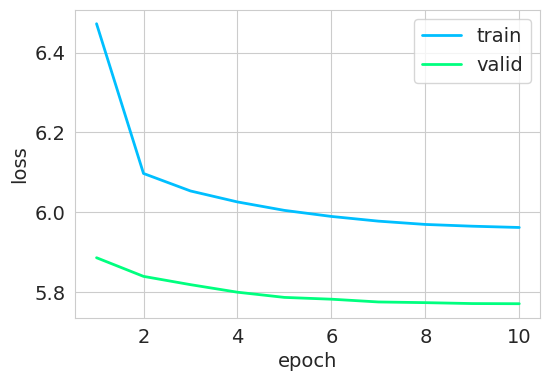

In [40]:
train(model, optimizer, scheduler, criterion, train_loader, valid_loader, NUM_EPOCHS)

In [41]:
embed_matrix = model.embeds.weight.detach()
embed_norms = (embed_matrix ** 2).sum(1).sqrt()

In [42]:
import re


def get_similarities(embed_vector):
    similarities = embed_matrix @ embed_vector / embed_norms / torch.norm(embed_vector)
    top_indices = similarities.argsort(descending=True)
    return similarities, top_indices


def get_similar(query, num_similar=5):
    print(f'Processing query \"{query}\"')
    split_query = re.split('([^a-zA-Z0-9])', query)
    index = vocab[split_query[0]]
    embed_vector = torch.clone(embed_matrix[index])
    if index > 0:
        print(f'Found word \"{split_query[0]}\" in vocab')
    else:
        print(f'Word \"{split_query[0]}\" not in vocab, using <unk>')

    for i in range(2, len(split_query), 2):
        index = vocab[split_query[i]]
        if index > 0:
            print(f'Found word \"{split_query[i]}\" in vocab, ', end='')
        else:
            print(f'Word \"{split_query[i]}\" not in vocab, using <unk>, ', end='')
        print(f'operation \"{split_query[i - 1]}\"')

        if split_query[i - 1] == '+':
            embed_vector += embed_matrix[index]
        elif split_query[i - 1] == '-':
            embed_vector -= embed_matrix[index]
        else:
            raise ValueError('Unknown operation')

    similarities, top_indices = get_similarities(embed_vector)

    itos = vocab.get_itos(top_indices)
    # print('Top similar:')
    # print(itos)
    for top_index in range(num_similar):
        print(f'    {itos[top_index]}: sim = {similarities[top_index]:.4f}')

In [43]:
get_similar('woman')

Processing query "woman"
Found word "woman" in vocab
    woman: sim = 0.4490
    girl: sim = 0.4416
    man: sim = 0.2973
    child: sim = 0.1826
    boy: sim = 0.2151


In [44]:
get_similar('kick')

Processing query "kick"
Found word "kick" in vocab
    kick: sim = 0.3100
    ECU: sim = 0.2419
    touchdown: sim = 0.2875
    Tech: sim = 0.5961
    goal: sim = 0.1676


In [45]:
get_similar('help')

Processing query "help"
Found word "help" in vocab
    help: sim = 0.3895
    try: sim = 0.4332
    accept: sim = 0.3217
    keep: sim = 0.1475
    bring: sim = 0.1839


In [46]:
v = get_similar('king-man', num_similar=10)

Processing query "king-man"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
    Church: sim = 0.0501
    Federal: sim = -0.1183
    Aviation: sim = 0.2063
    Education: sim = -0.1499
    Forces: sim = 0.0495
    Emperor: sim = 0.0931
    Supreme: sim = 0.0687
    Board: sim = 0.0460
    king: sim = 0.1907
    Bureau: sim = -0.0010


In [47]:
v = get_similar('king-man+woman', num_similar=10)

Processing query "king-man+woman"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
Found word "woman" in vocab, operation "+"
    king: sim = 0.4415
    saint: sim = 0.2980
    bishop: sim = 0.4331
    queen: sim = 0.0412
    poem: sim = 0.2322
    Catherine: sim = 0.4995
    reincarnation: sim = 0.4585
    Trujillo: sim = 0.4189
    Bolívar: sim = 0.3935
    Palmyra: sim = 0.1609


In [48]:
get_similar('king')

Processing query "king"
Found word "king" in vocab
    king: sim = 0.5124
    King: sim = 0.3197
    Odaenathus: sim = 0.4687
    queen: sim = 0.0874
    Lord: sim = 0.2640


## Gensim

Обучим Word2Vec с помощью библиотеки gensim

In [49]:
# !pip install gensim

In [50]:
from gensim.models import Word2Vec
model = Word2Vec(train_data, 
                 vector_size=32,      # embedding vector size
                 min_count=5,  # consider words that occured at least 5 times
                 window=5).wv  # define context as a 5-word window around the target word

In [51]:
dir(model)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adapt_by_suffix',
 '_load_specials',
 '_log_evaluate_word_analogies',
 '_save_specials',
 '_smart_save',
 '_upconvert_old_d2vkv',
 '_upconvert_old_vocab',
 'add_lifecycle_event',
 'add_vector',
 'add_vectors',
 'allocate_vecattrs',
 'closer_than',
 'cosine_similarities',
 'distance',
 'distances',
 'doesnt_match',
 'evaluate_word_analogies',
 'evaluate_word_pairs',
 'expandos',
 'fill_norms',
 'get_index',
 'get_mean_vector',
 'get_normed_vectors',
 'get_vecattr',
 'get_vector',
 'has_index_for',
 'index2entity',
 'index2word',
 'index_to_key'

In [52]:
model.most_similar(positive=["king", "woman"], negative=["man"])

[('Lady', 0.8640601634979248),
 ('poet', 0.8455675840377808),
 ('murder', 0.8446229100227356),
 ('Tintin', 0.8339477181434631),
 ('writings', 0.8305248022079468),
 ('Tennyson', 0.8295284509658813),
 ('chief', 0.822777509689331),
 ('minister', 0.8197644948959351),
 ('editor', 0.8165234327316284),
 ('assassination', 0.8159504532814026)]

In [53]:
model.most_similar('woman')

[('child', 0.9510834813117981),
 ('girl', 0.9501654505729675),
 ('man', 0.9136412143707275),
 ('boy', 0.8762853145599365),
 ('person', 0.8683487772941589),
 ('hero', 0.8591142892837524),
 ('figure', 0.8586791157722473),
 ('great', 0.8454151153564453),
 ('image', 0.8415393829345703),
 ('teacher', 0.8402650952339172)]

In [54]:
model.most_similar('cat')

[('Inari', 0.9437200427055359),
 ('bone', 0.9363409280776978),
 ('oxide', 0.9333041310310364),
 ('carbon', 0.9313734769821167),
 ('buff', 0.9279050230979919),
 ('gleba', 0.925538182258606),
 ('cloth', 0.9234979152679443),
 ('gray', 0.9225624799728394),
 ('marrow', 0.9157761335372925),
 ('puma', 0.9151497483253479)]

# FastText for sentiment classification

In [55]:
# %%bash
# kaggle datasets download -d shivkumarganesh/bumble-dating-app-google-play-store-review
# unzip bumble-dating-app-google-play-store-review.zip

In [67]:
!pip install fasttext

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=339621 sha256=3c8d95c2307f3cb603727bf9b6134157aee47a0115201e331b242f84667e3a32
  Stored in directory: /home/free001style/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fasttext]


In [56]:
import pandas as pd
import fasttext
import fasttext.util

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

In [57]:
data = pd.read_csv('bumble_google_play_reviews.csv')
data = data[data.content.notna()]
data

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6d82d923-6af6-4d32-85ea-b762ba643b20,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,dont pay for the subscription. theyre SCAMMING...,1,0,NaN,2025-11-16 00:04:38,NaN,NaN,NaN
1,550080f8-b481-4819-9b64-3bd0f75e56f9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Don't waste your time on the app, it doesn't w...",1,0,5.442.0,2025-11-15 22:44:23,NaN,NaN,5.442.0
2,b766c303-2e05-4cc8-8469-edd12f5c232e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The app is heavily skewed to have weird people...,1,0,5.365.0,2025-11-15 22:39:08,NaN,NaN,5.365.0
3,8e1651a5-7419-43bd-802a-02cb779e13cc,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,premium plus is advertised as offering 2 spotl...,1,0,5.442.0,2025-11-15 21:57:10,Hi there! We're glad you're no longer experien...,2019-05-06 09:00:34,5.442.0
4,a4a76a3b-f00c-44d9-be5f-640fa315521b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Bumble is a genuinely awful app. It deleted on...,1,0,5.442.0,2025-11-15 21:16:35,NaN,NaN,5.442.0
...,...,...,...,...,...,...,...,...,...,...,...
173438,61bc7cdc-3085-4631-ac95-d8e42e2e0742,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally here!,5,54,1.0.1,2015-12-01 02:17:24,NaN,NaN,1.0.1
173439,24d07489-88ad-496a-80ce-8f137c130323,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally!,5,74,1.0.1,2015-12-01 02:09:05,NaN,NaN,1.0.1
173440,22a42d0d-7a12-400d-a2af-826f35d21581,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Finally, an app where women have to start the ...",4,2,1.0.1,2015-12-01 00:18:53,NaN,NaN,1.0.1
173441,2480a41f-8863-4948-9f83-7d856bd9dc78,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,At last we have Android version!,5,60,1.0.0,2015-11-30 21:27:51,NaN,NaN,1.0.0


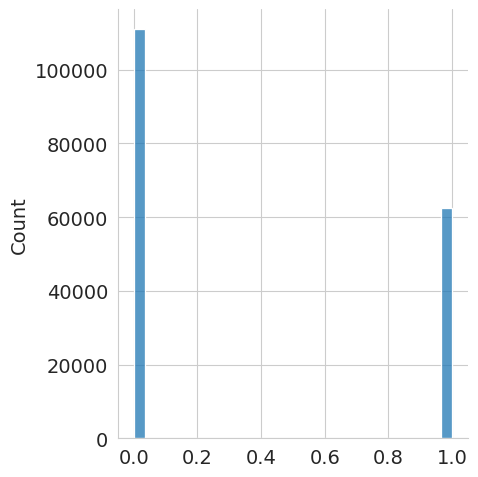

In [58]:
X = data.content.apply(tokenizer.tokenize).to_list()
y = (data.score >= 4).to_numpy().astype(int)
_ = sns.displot(y)

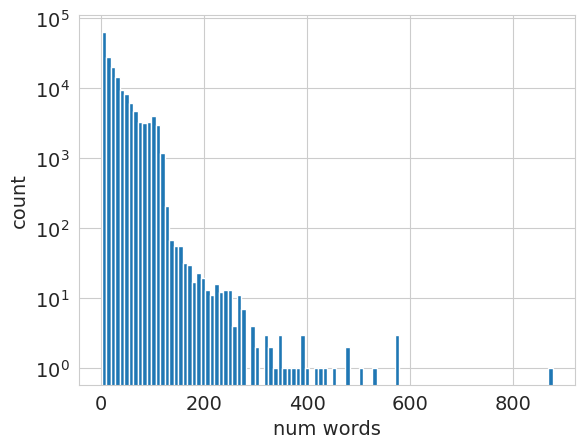

In [59]:
plt.hist([len(sent) for sent in X], bins=100)
plt.yscale('log')
plt.ylabel('count')
plt.xlabel('num words')
plt.show()

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
len(X_train), len(X_test)

(130069, 43357)

In [61]:
fasttext.util.download_model('en', if_exists='ignore')
ft = fasttext.load_model('cc.en.300.bin')

In [62]:
ft.get_word_vector('mother').shape

(300,)

In [63]:
ft.get_nearest_neighbors('mother')

[(0.8316885828971863, 'father'),
 (0.8139842748641968, 'grandmother'),
 (0.8042423725128174, 'daughter'),
 (0.7595430612564087, 'aunt'),
 (0.7551708221435547, 'stepfather'),
 (0.7433159947395325, 'mom'),
 (0.7390366792678833, 'step-father'),
 (0.7379246950149536, 'stepmother'),
 (0.7268661856651306, 'step-mother'),
 (0.7265076041221619, 'sister')]

In [64]:
ft.get_nearest_neighbors('king')

[(0.7550359964370728, 'kings'),
 (0.7068519592285156, 'queen'),
 (0.7060439586639404, 'king-'),
 (0.6811205148696899, 'king.'),
 (0.660710871219635, 'king.The'),
 (0.6591265797615051, 'King'),
 (0.6495252251625061, 'prince'),
 (0.6278106570243835, '-king'),
 (0.6183920502662659, 'monarch'),
 (0.6070184707641602, 'queen-mother')]

In [65]:
emb = ft.get_word_vector('king') - ft.get_word_vector('man') + ft.get_word_vector('woman')

In [66]:
words = []
all_embs = []

for word in ft.get_words():
    words.append(word)
    all_embs.append(ft.get_word_vector(word))

all_embs = np.array(all_embs)
def cosine_similarity(a, b):
    a_norm = a / np.linalg.norm(a)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    return np.dot(b_norm, a_norm)

similarities = cosine_similarity(emb, all_embs)
argsort_idx = np.argsort(-similarities)

for i in range(10):
    print(words[argsort_idx[i]], similarities[argsort_idx[i]])

king 0.72866744
queen 0.6542679
kings 0.54102814
queen-mother 0.5250691
Queen 0.507442
royal 0.500453
king- 0.49450076
queens 0.49149513
monarch 0.4913708
queenship 0.48369986


In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [68]:
X_train_sents = [' '.join(sent) for sent in X_train]
X_test_sents = [' '.join(sent) for sent in X_test]

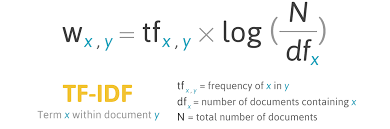

In [69]:
tf_idf = TfidfVectorizer(min_df=5).fit(X_train_sents)
tf_idf_train = tf_idf.transform(X_train_sents)
tf_idf_test = tf_idf.transform(X_test_sents)

tf_idf_train.shape, tf_idf_test.shape

((130069, 9503), (43357, 9503))

In [70]:
lr = LogisticRegression(max_iter=1000).fit(tf_idf_train, y_train)

In [71]:
print(f'Tf-idf + LogRegr train acc: {accuracy_score(lr.predict(tf_idf_train), y_train):.4f}')
print(f'Tf-idf + LogRegr test acc: {accuracy_score(lr.predict(tf_idf_test), y_test):.4f}')

Tf-idf + LogRegr train acc: 0.9028
Tf-idf + LogRegr test acc: 0.8957


In [72]:
def get_sentence_embedding(sent):
    embeds = []
    for word in sent:
        embeds += [ft.get_word_vector(word)]

    return np.stack(embeds, axis=0).mean(0)

In [73]:
train_embeds = np.stack([get_sentence_embedding(sent) for sent in X_train], axis=0)
test_embeds = np.stack([get_sentence_embedding(sent) for sent in X_test], axis=0)

In [74]:
lr = LogisticRegression(max_iter=1000).fit(train_embeds, y_train)

In [75]:
print(f'FastText + LogRegr train acc: {accuracy_score(lr.predict(train_embeds), y_train):.4f}')
print(f'FastText + LogRegr test acc: {accuracy_score(lr.predict(test_embeds), y_test):.4f}')

FastText + LogRegr train acc: 0.8610
FastText + LogRegr test acc: 0.8624


In [76]:
BATCH_SIZE = 128
MAX_SEQUENCE_LENGTH = 256
MODEL_BLOCKS = 2
MODEL_CHANNELS = 300
NUM_EPOCHS = 5

In [86]:
class EmbeddingsDataset(Dataset):
    def __init__(self, sents, targets, max_length):
        super().__init__()
        self.max_length = max_length
        self.sents = sents
        self.targets = targets
    
    def __len__(self):
        return len(self.sents)

    def __getitem__(self, item):
        sent = self.sents[item]
        length = min(len(sent), self.max_length)

        embeds = []
        for word in sent[:length]:
            embeds += [torch.from_numpy(ft.get_word_vector(word).astype(np.float32))]
        
        embeds = torch.stack(embeds, dim=1)
        padding = torch.zeros((embeds.shape[0], self.max_length - length))
        embeds = torch.cat([embeds, padding], dim=1)
        target = self.targets[item]
        return embeds, length, target

In [87]:
train_set = EmbeddingsDataset(X_train, y_train, max_length=MAX_SEQUENCE_LENGTH)
test_set = EmbeddingsDataset(X_test, y_test, max_length=MAX_SEQUENCE_LENGTH)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, num_workers=4,
                          pin_memory=True, shuffle=True, prefetch_factor=4)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, num_workers=4, prefetch_factor=4,
                         pin_memory=True)

In [94]:
class BasicBlock(nn.Module):
    def __init__(self, num_channels, kernel_size):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(num_channels, num_channels, kernel_size,
                               padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(num_channels)
        self.conv2 = nn.Conv1d(num_channels, num_channels, kernel_size,
                               padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(num_channels)
        self.relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out + x)
        return out

class TextCNN(nn.Module):
    def __init__(self, num_blocks, num_channels, num_classes, kernel_size=5):
        super().__init__()
        self.backbone = nn.Sequential(
            *[BasicBlock(num_channels, kernel_size) for _ in range(num_blocks)]
        )

        self.classifier = nn.Linear(num_channels, num_classes)

    @staticmethod
    def get_lengths_mask(embeds, lengths):
        mask = torch.arange(embeds.shape[-1]).unsqueeze(0).to(embeds.device)
        mask = (mask < lengths.unsqueeze(1)).to(torch.float)
        return mask.unsqueeze(1)

    def forward(self, embeds, lengths):
        # embeds: (B, C, T), lengths: (B, )
        features = self.backbone(embeds)
        # features: (B, C, T)
        mask = self.get_lengths_mask(embeds, lengths)
        # mask: (B, 1, T)
        features = (features * mask).sum(-1) / lengths.unsqueeze(1)
        # features: (B, C)
        logits = self.classifier(features)
        # logits: (B, num_classes)
        return logits

In [95]:
from IPython.display import clear_output
from tqdm.notebook import tqdm


def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test', color='springgreen', linewidth=2)
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train',
                color='deepskyblue', linewidth=2)
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test',
                color='springgreen', linewidth=2)
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [96]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for embeds, lengths, labels in tqdm(train_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        embeds = embeds[..., :lengths.max()]

        optimizer.zero_grad()
        logits = model(embeds, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * embeds.shape[0]
        train_accuracy += (logits.argmax(1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss, valid_accuracy = 0.0, 0.0
    model.eval()
    for embeds, lengths, labels in tqdm(valid_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        embeds = embeds[..., :lengths.max()]

        logits = model(embeds, lengths)
        loss = criterion(logits, labels)

        valid_loss += loss.item() * embeds.shape[0]
        valid_accuracy += (logits.argmax(1) == labels).sum().item()

    valid_loss /= len(valid_loader.dataset)
    valid_accuracy /= len(valid_loader.dataset)
    return valid_loss, valid_accuracy


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs):
    train_losses, valid_losses = [], []
    train_accuracies, valid_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss, valid_accuracy = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        train_accuracies += [train_accuracy]
        valid_losses += [valid_loss]
        valid_accuracies += [valid_accuracy]
        plot_losses(train_losses, valid_losses, train_accuracies, valid_accuracies)

In [97]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [98]:
model = TextCNN(num_blocks=MODEL_BLOCKS, num_channels=MODEL_CHANNELS, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

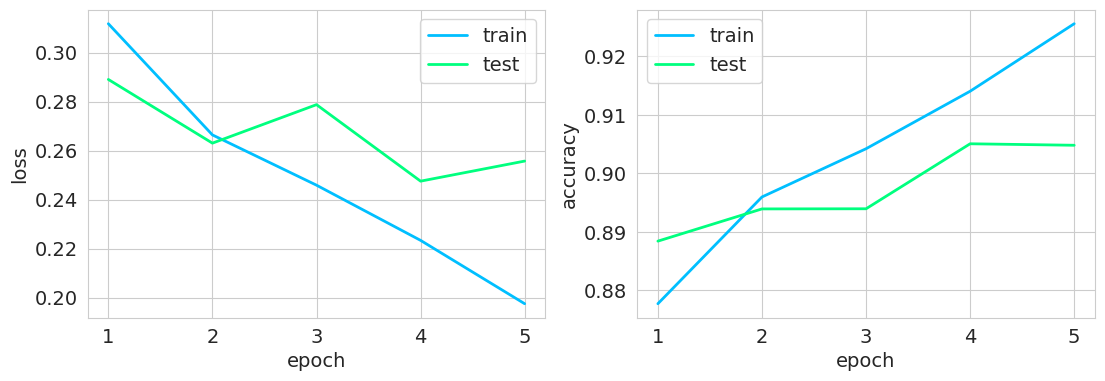

In [99]:
train(model, optimizer, scheduler, criterion, train_loader, test_loader, NUM_EPOCHS)